# Optimization Intro-Hill Climbing

In [2]:
%matplotlib inline

In [3]:
from numpy.random import rand
from numpy.random import randn
import matplotlib.pyplot as plt
import numpy as np

In [4]:
def objective(x):
    return 0

In [5]:
# define range for input
bounds = np.array([[-5.0,5.0]])
bounds

array([[-5.,  5.]])

In [6]:
len(bounds)

1

In [7]:
bounds[:,1] - bounds[:,0]

array([10.])

In [8]:
# generate an initial point
solution = bounds[:, 0] + rand(len(bounds)) * (bounds[:, 1]- bounds[:,0])
solution

array([-1.98677937])

In [9]:
# evaluate the initial point
solution_eval = objective(solution)
solution_eval

0

In [10]:
n_iterations = 10
step_size = 0.1

for i in range(n_iterations):
    candidate = solution + (randn(len(bounds)) * step_size)
    candidate_eval = objective(candidate)
    
    if candidate_eval <= solution_eval:
        # store the new point
        solution, solution_eval = candidate, candidate_eval
        # report progress
        print('>%d f(%s) = %.5f' % (i, solution, solution_eval))

>0 f([-1.85513753]) = 0.00000
>1 f([-1.80275642]) = 0.00000
>2 f([-1.87076793]) = 0.00000
>3 f([-1.61349086]) = 0.00000
>4 f([-1.65133641]) = 0.00000
>5 f([-1.67788584]) = 0.00000
>6 f([-1.73931835]) = 0.00000
>7 f([-1.7860026]) = 0.00000
>8 f([-1.83620838]) = 0.00000
>9 f([-1.79716248]) = 0.00000


In [11]:
def hillclimbing(objective, bounds, n_iterations, step_size, debug=True):
    all_candidates = []
    
    # generate an initial point
    solution = bounds[:, 0] + rand(len(bounds)) * (bounds[:, 1]- bounds[:, 0])
    solution_eval = objective(solution)
    
    # run the hill climbing
    for i in range(n_iterations):
        # take a step
        candidate = solution + randn(len(bounds)) * step_size
        all_candidates.append(candidate)
        
        # evaluate candidate points
        candidate_eval = objective(candidate)
        
        # check if we should keep the new points
        if candidate_eval <= solution_eval:
            # store the new point
            solution, solution_eval = candidate, candidate_eval
            # report progress
            if debug:
                print('>%d f(%s) = %.5f' % (i, solution, solution_eval))
                
    return [solution, solution_eval, all_candidates]

In [12]:
# objective function
def objective(x):
    return (x-2)**2.0

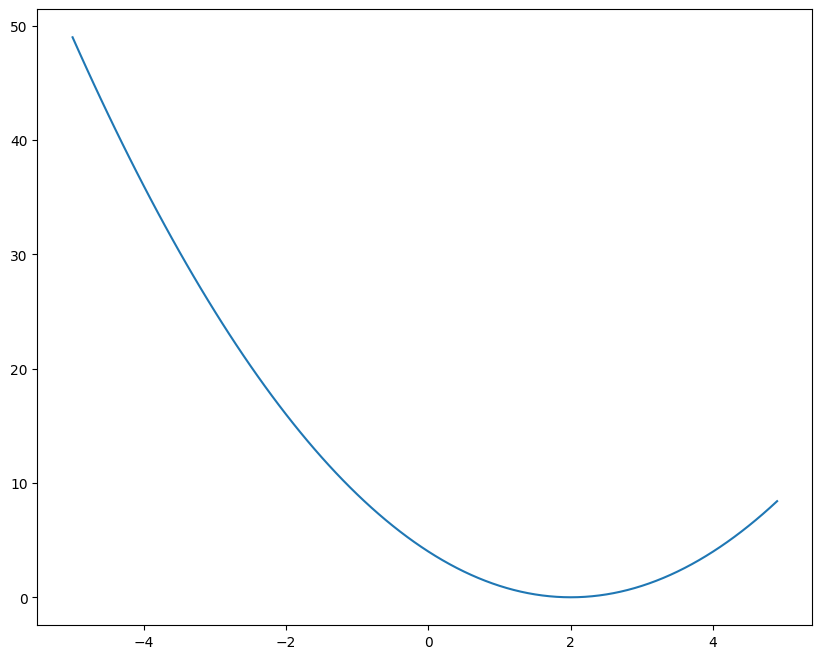

In [13]:
x_range = np.arange(-5.0, 5.0, 0.1)
y_range = objective(x_range)
plt.figure(figsize = (10, 8))
plt.plot(x_range,y_range)
plt.show()

In [14]:
# seed the pseudorandom number generator
np.random.seed(5)
# define range for input
bounds = np.asarray([[-5.0,5.0]])

# define the total iterations
n_iterations = 1000

# define the maximum step size
step_size = 0.1

# perform the hill climbing search
best, score, all_candidates = hillclimbing(objective, bounds, n_iterations, step_size)

print('f(%s) = %f' % (best, score))

>1 f([-2.74290923]) = 22.49519
>3 f([-2.65873147]) = 21.70378
>4 f([-2.52197291]) = 20.44824
>5 f([-2.46450214]) = 19.93178
>7 f([-2.44740961]) = 19.77945
>9 f([-2.28364676]) = 18.34963
>12 f([-2.19245939]) = 17.57672
>14 f([-2.01001538]) = 16.08022
>15 f([-1.86425287]) = 14.93245
>22 f([-1.79913002]) = 14.43339
>24 f([-1.57525573]) = 12.78245
>25 f([-1.55047719]) = 12.60589
>26 f([-1.51783757]) = 12.37518
>27 f([-1.49118756]) = 12.18839
>28 f([-1.45344116]) = 11.92626
>30 f([-1.33055275]) = 11.09258
>32 f([-1.17805016]) = 10.10000
>33 f([-1.15189314]) = 9.93443
>36 f([-1.03852644]) = 9.23264
>37 f([-0.99135322]) = 8.94819
>38 f([-0.79448984]) = 7.80917
>39 f([-0.69837955]) = 7.28125
>42 f([-0.69317313]) = 7.25318
>46 f([-0.61801423]) = 6.85400
>48 f([-0.48799625]) = 6.19013
>50 f([-0.22149135]) = 4.93502
>54 f([-0.20017144]) = 4.84075
>57 f([-0.15994446]) = 4.66536
>60 f([-0.15492485]) = 4.64370
>61 f([-0.03572481]) = 4.14418
>62 f([0.10263483]) = 3.59999
>64 f([0.10784703]) = 3.58024

C:\Users\dell\AppData\Local\Temp\ipykernel_4692\1550507675.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('>%d f(%s) = %.5f' % (i, solution, solution_eval))
C:\Users\dell\AppData\Local\Temp\ipykernel_4692\1240724759.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('f(%s) = %f' % (best, score))


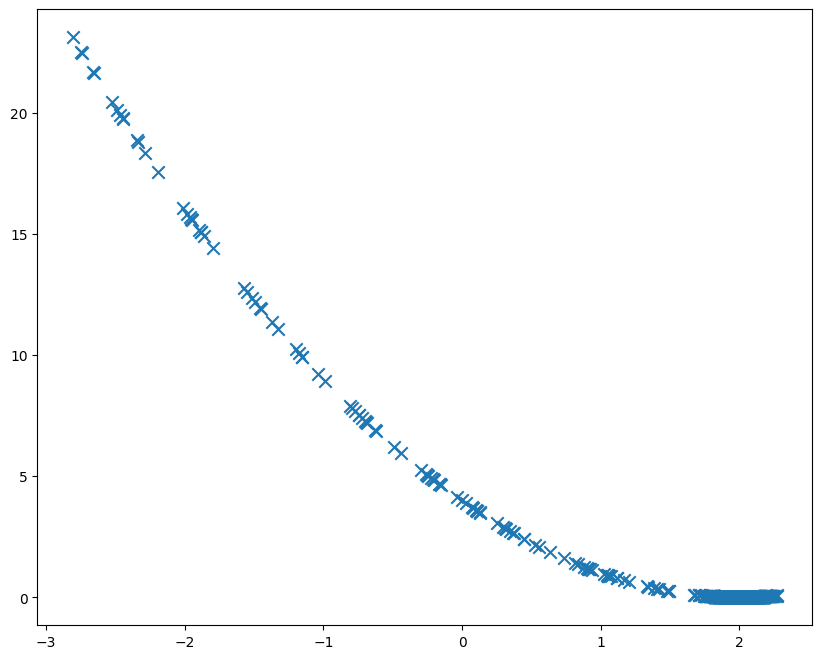

In [15]:
all_candidates = np.asarray(all_candidates)
y_all = objective(all_candidates)
plt.figure(figsize=(10,8))
plt.scatter(all_candidates, y_all, marker='x', s=80)
# plt.xlim([-1, 2.1])
# plt.xlim([1.99, 2.01])
plt.show()

In [16]:
from numpy import sin, cos
# objective function
def objective(x):
    return sin(x) + cos(x/2)

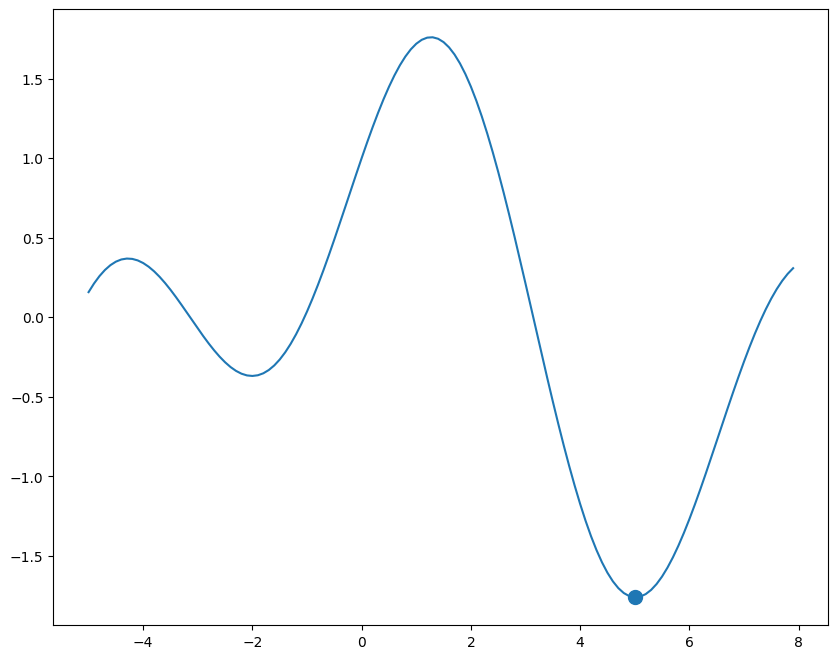

In [17]:
x_range = np.arange(-5.0, 8.0, 0.1)
y_range = objective(x_range)
plt.figure(figsize=(10,8))
plt.plot(x_range,y_range)
plt.scatter(5, objective(5), s= 100)
plt.show()

In [18]:
# seed the pseudorandom number generator
np.random.seed(5)
# define range for input
bounds = np.asarray([[0.0, 6.0]])

# define the total iterations
n_iterations = 100

# define the maximum step size
step_size = 0.1

# perform the hill climbing search
best, score, all_candidates = hillclimbing(objective, bounds, n_iterations, step_size)

print('f(%s) = %f ' % (best, score))

>1 f([1.36911808]) = 1.75443
>3 f([1.45329585]) = 1.74051
>4 f([1.5900544]) = 1.70008
>5 f([1.64752517]) = 1.67652
>7 f([1.66461771]) = 1.66877
>9 f([1.82838056]) = 1.57744
>12 f([1.91956792]) = 1.51349
>14 f([2.10201194]) = 1.35889
>15 f([2.24777445]) = 1.21165
>22 f([2.3128973]) = 1.13964
>24 f([2.53677159]) = 0.86644
>25 f([2.56155013]) = 0.83403
>26 f([2.59418974]) = 0.79077
>27 f([2.62083976]) = 0.75498
>28 f([2.65858616]) = 0.70361
>30 f([2.78147457]) = 0.53147
>32 f([2.93397716]) = 0.30975
>33 f([2.96013418]) = 0.27107
>36 f([3.07350087]) = 0.10208
>37 f([3.12067409]) = 0.03138
>38 f([3.31753747]) = -0.26290
>39 f([3.41364777]) = -0.40432
>42 f([3.41885418]) = -0.41191
>46 f([3.49401309]) = -0.52047
>48 f([3.62403106]) = -0.70283
>50 f([3.89053597]) = -1.04665
>54 f([3.91185587]) = -1.07201
>57 f([3.95208285]) = -1.11887
>60 f([3.95710247]) = -1.12462
>61 f([4.0763025]) = -1.25495
>62 f([4.21466214]) = -1.38983
>64 f([4.21987434]) = -1.39455
>66 f([4.24295866]) = -1.41510
>71 f(

C:\Users\dell\AppData\Local\Temp\ipykernel_4692\1550507675.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('>%d f(%s) = %.5f' % (i, solution, solution_eval))
C:\Users\dell\AppData\Local\Temp\ipykernel_4692\1435614533.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('f(%s) = %f ' % (best, score))


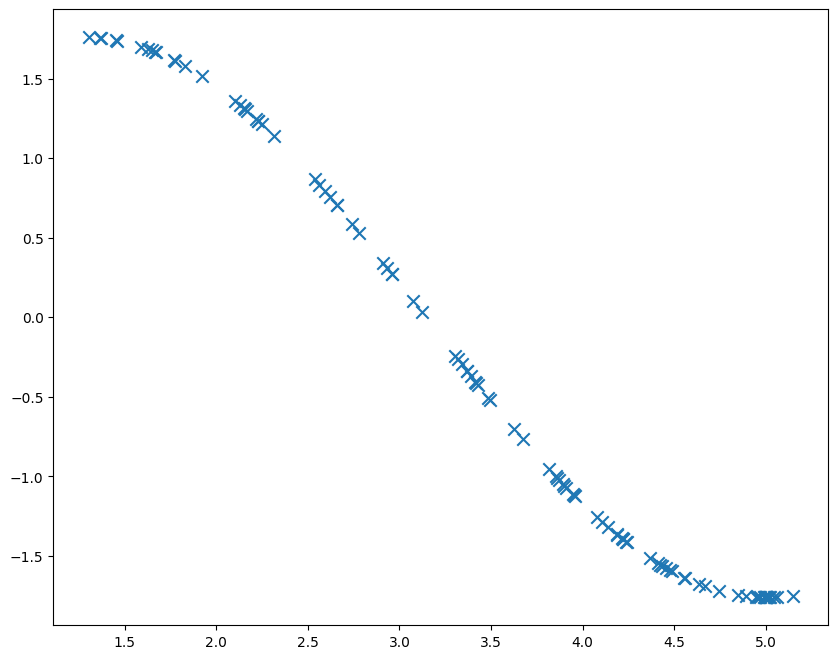

In [19]:
all_candidates = np.asarray(all_candidates)
y_all = objective(all_candidates)
plt.figure(figsize=(10,8))
plt.scatter(all_candidates, y_all, marker='x', s=80)
# plt.xlim([-1, 2.1])
# plt.xlim([1.99, 2.01])
plt.show()

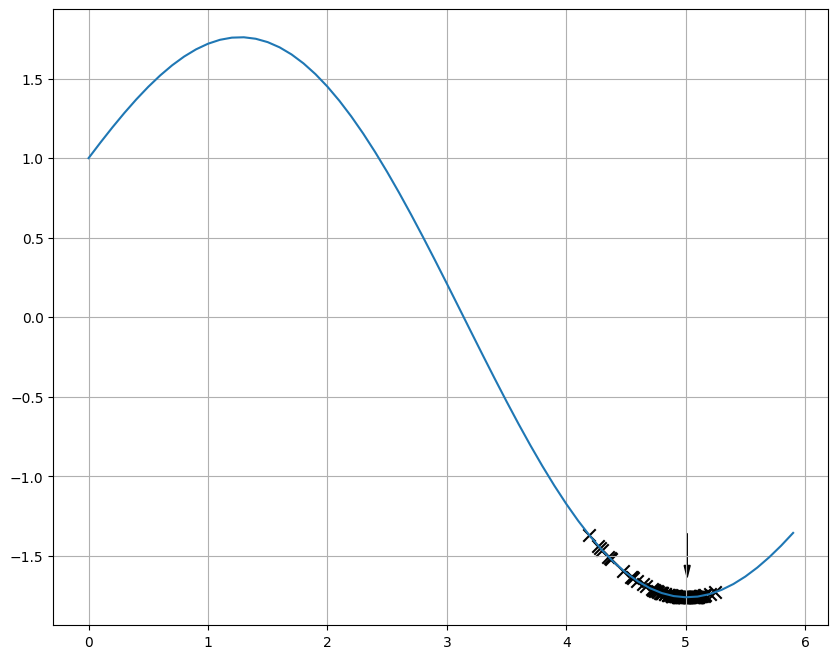

In [21]:
# Run several times to get different answers ...

# define range for input 
bounds = np.asarray([[0.0, 6.0]])
x_range = np.arange(bounds[0,0], bounds[0,1], 0.1)

# define the total iterations
n_iterations = 100

# define the maximum step size
step_size = 0.1
# step_size = 1.5

# perform the hill climbing search
best, score, all_candidates = hillclimbing(objective, bounds, n_iterations, step_size, debug=False)

all_candidates = np.asarray(all_candidates)
y_all = objective(all_candidates)
plt.figure(figsize=(10,8))
plt.grid()
plt.plot(x_range, objective(x_range))
plt.scatter(all_candidates, y_all, marker='x', color= 'black', s=80)
plt.arrow(best[0], objective(best[0])+0.4, 0, -0.2, head_width=0.05, color='black')

plt.show()

Q: What happen when the number of dimensions increased?

# **Maximum, Not Minimum?**

Can we do the same algorithum for Maximum instead of Minimum

In [22]:
def objective_2(x):
    """We are invesing the function by multiply it with -1 as it is odd function 
    f(-x)= -f(x)"""
    return -1 * objective(x)

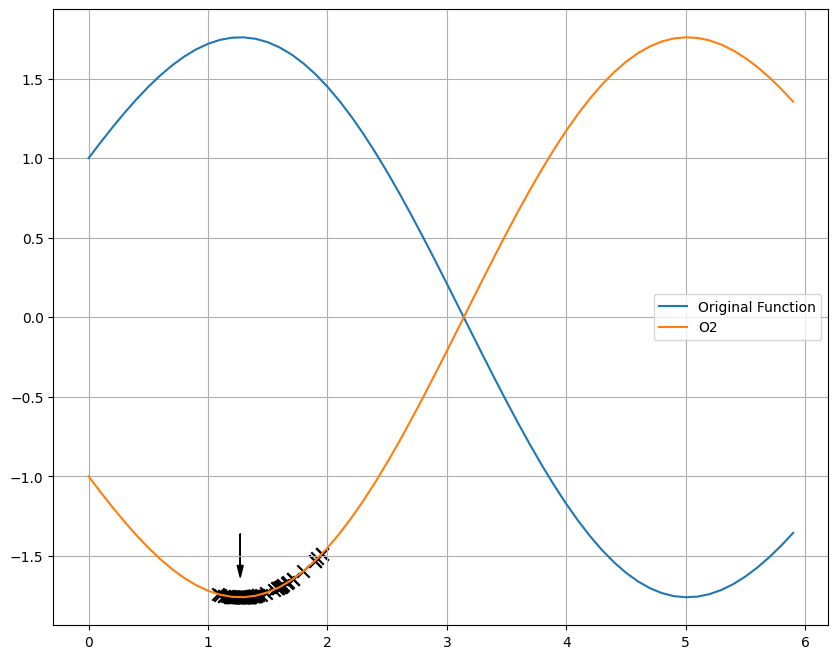

In [29]:
# Run several times to get different answers ...

# define range for input 
bounds = np.asarray([[0.0, 6.0]])
x_range = np.arange(bounds[0,0], bounds[0,1], 0.1)

# define the total iterations
n_iterations = 100

# define the maximum step size
step_size = 0.1
# step_size = 1.5

# perform the hill climbing search
best, score, all_candidates = hillclimbing(objective_2, bounds, n_iterations, step_size, debug=False)

all_candidates = np.asarray(all_candidates)
y_1 = objective(all_candidates)
y_2 = objective_2(all_candidates)
plt.figure(figsize=(10,8))
plt.grid()
plt.plot(x_range, objective(x_range), label='Original Function')
plt.plot(x_range, objective_2(x_range), label='O2')
plt.scatter(all_candidates, y_2, marker='x', color= 'black', s=80)
plt.arrow(best[0], objective_2(best[0])+0.4, 0, -0.2, head_width=0.05, color='black')

plt.legend()
plt.show()

In [30]:
# As you can see the minimum of our O2 is the maximum of original function the reason is that by reversing all maximum of the function are converted to minimum and vice versa so the mimium of this
# function which we made (objective_2) is acually the maximum of the original function